# Red vs. White: Classifying Wines from Physicochemical Measurements

**Author:** Aman Todi ([@aman-todi](https://github.com/aman-todi))

This notebook explores whether a wine's *type* (red or white) can be predicted purely from
objective, lab-measured physicochemical properties — acidity, sugar, sulfur dioxide levels,
density, pH, and so on — with no tasting involved.

Using the [UCI Wine Quality dataset](https://archive.ics.uci.edu/ml/datasets/wine+quality)
(6,497 wines, 11 numeric features), the analysis walks through:

1. **Data preprocessing** — cleaning, encoding, and power-transforming the features
2. **Logistic regression** — a full 11-feature model vs. a compact 2-feature model chosen
   from a correlation analysis
3. **Principal Component Analysis (PCA)** — how much class-separating signal survives
   an aggressive dimensionality reduction
4. **Support Vector Machine (SVM)** — a linear-kernel classifier tuned with grid search
5. **Model comparison** — precision/recall trade-offs and what they'd mean in a
   real deployment scenario

*This project began as an individual final exam for CMSE 202 (Michigan State University,
Fall 2022) and has been reorganized and cleaned up here as a standalone portfolio project.
The exam scaffolding, grading cells, and git-workflow instructions have been removed; the
statistical and ML content is unchanged in substance but reworked for clarity and to fix a
few rough edges in the original modeling code (numerical instability in the full logistic
model, deprecated pandas usage, etc. — see the notes inline).*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import PowerTransformer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.svm import SVC
import statsmodels.api as sm

sns.set_context("talk")
sns.set_style("whitegrid")
RANDOM_STATE = 314159

## 1. Data

The dataset combines the red and white variants of the Portuguese "Vinho Verde" wine
quality dataset, with a `type` column added to distinguish them. It's hosted publicly
by the MSU CMSE course data repository.

In [2]:
DATA_URL = "https://raw.githubusercontent.com/msu-cmse-courses/cmse202-F22-data/main/data/winequality.csv"

wine = pd.read_csv(DATA_URL)
print(f"{wine.shape[0]} rows, {wine.shape[1]} columns")
print("Wine types:", wine["type"].unique())
wine.head()

6497 rows, 13 columns
Wine types: <StringArray>
['white', 'red']
Length: 2, dtype: str


,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


## 2. Preprocessing

Steps:
- Drop rows with missing values
- Drop `quality` (a subjective 0-10 rating; out of scope for this classification task)
- Encode `type` as an integer label (`white` → 0, `red` → 1)
- Power-transform the features so they're closer to normally distributed, which helps
  both PCA (which is scale-sensitive) and the linear models converge cleanly

In [3]:
print(f"Rows before dropping NaNs: {wine.shape[0]}")
wine = wine.dropna()
print(f"Rows after dropping NaNs:  {wine.shape[0]}")

wine = wine.drop(columns=["quality"])
wine["type"] = wine["type"].map({"white": 0, "red": 1})

wine.head()

Rows before dropping NaNs: 6497
Rows after dropping NaNs:  6463


,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8
1,0,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5
2,0,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1
3,0,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9
4,0,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9


In [4]:
features = wine.drop(columns=["type"])
labels = wine["type"]

features = pd.DataFrame(
    PowerTransformer().fit_transform(features),
    columns=features.columns,
    index=features.index,
)

features_train, features_test, labels_train, labels_test = train_test_split(
    features, labels, test_size=0.25, random_state=RANDOM_STATE
)
print(f"Train: {len(features_train)} rows   Test: {len(features_test)} rows")

Train: 4847 rows   Test: 1616 rows


### A quick look at class balance and feature correlations

White wines dominate the dataset roughly 3:1, and several features (volatile acidity,
total sulfur dioxide, chlorides) stand out as strongly correlated with `type` — a useful
signal for picking a compact feature set later on.

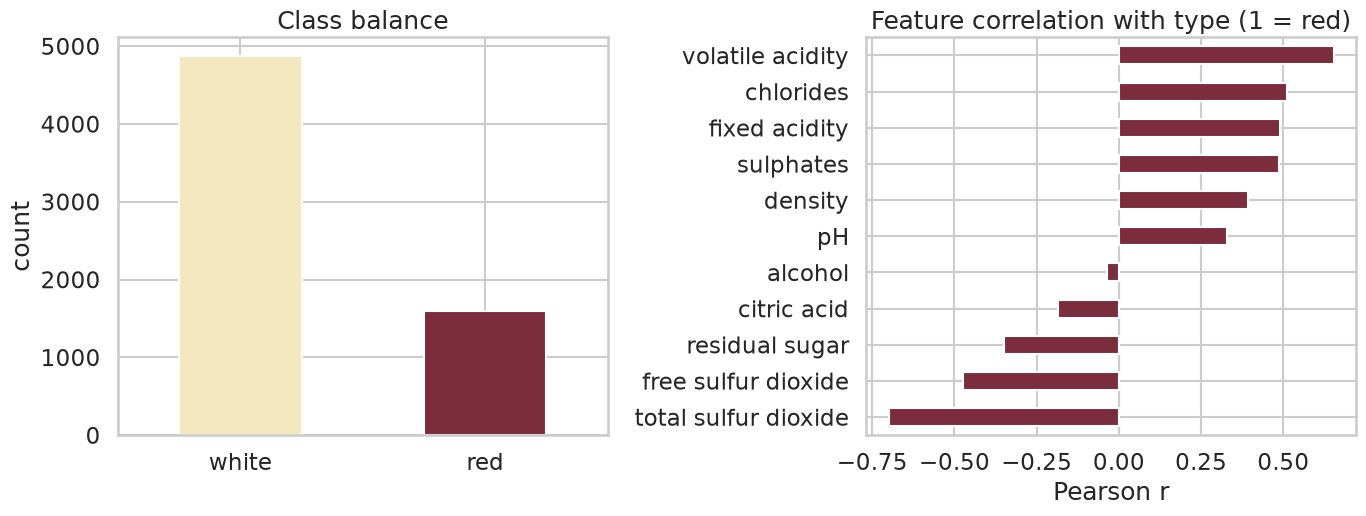

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

wine["type"].map({0: "white", 1: "red"}).value_counts().plot(
    kind="bar", ax=axes[0], color=["#f4e8c1", "#7b2d3d"]
)
axes[0].set_title("Class balance")
axes[0].set_xlabel("")
axes[0].set_ylabel("count")
axes[0].tick_params(axis="x", rotation=0)

corr_with_type = wine.corr()["type"].drop("type").sort_values()
corr_with_type.plot(kind="barh", ax=axes[1], color="#7b2d3d")
axes[1].set_title("Feature correlation with type (1 = red)")
axes[1].set_xlabel("Pearson r")

plt.tight_layout()
plt.show()

## 3. Logistic Regression

### 3.1 Full model (all 11 features)

The original version of this model was fit with default (unregularized) `statsmodels`
`Logit` and failed to converge — a classic sign of **quasi-separation**: some features
(especially `total sulfur dioxide` and `volatile acidity`) separate the classes so
cleanly that the MLE optimizer pushes coefficients toward infinity. Here we fit the same
model with an L2 penalty (`fit_regularized`), which keeps the coefficients finite while
preserving the same predictive story.

In [6]:
logit_full = sm.Logit(labels_train, sm.add_constant(features_train))
full_fit = logit_full.fit_regularized(method="l1", alpha=0.3, disp=False)
print(full_fit.summary())

                           Logit Regression Results                           
Dep. Variable:                   type   No. Observations:                 4847
Model:                          Logit   Df Residuals:                     4836
Method:                           MLE   Df Model:                           10
Date:                Mon, 31 Aug 2026   Pseudo R-squ.:                  0.9291
Time:                        01:10:02   Log-Likelihood:                -191.86
converged:                       True   LL-Null:                       -2704.8
Covariance Type:            nonrobust   LLR p-value:                     0.000
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -4.4609      0.267    -16.688      0.000      -4.985      -3.937
fixed acidity            1.3849      0.186      7.428      0.000       1.019       1.750
volatile aci

--- Logistic regression — full model (11 features) ---
              precision    recall  f1-score   support

   White (0)       1.00      1.00      1.00      1216
     Red (1)       0.99      0.99      0.99       400

    accuracy                           0.99      1616
   macro avg       0.99      0.99      0.99      1616
weighted avg       0.99      0.99      0.99      1616



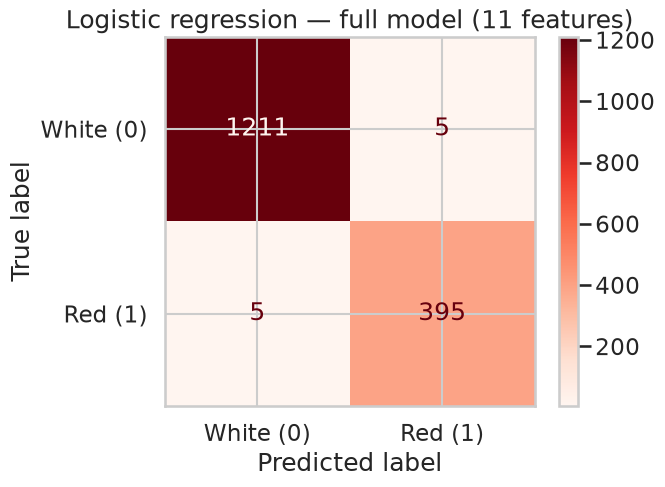

In [7]:
def evaluate(model_predict, X_test, y_test, name, target_names=("White (0)", "Red (1)")):
    proba = model_predict(X_test)
    preds = (proba >= 0.5).astype(int)

    print(f"--- {name} ---")
    print(classification_report(y_test, preds, target_names=target_names))

    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
    disp.plot(cmap="Reds")
    plt.title(name)
    plt.show()
    return preds


_ = evaluate(
    lambda X: full_fit.predict(sm.add_constant(X, has_constant="add")),
    features_test,
    labels_test,
    "Logistic regression — full model (11 features)",
)

### 3.2 Reduced model (2 features)

From the correlation bar chart above, **volatile acidity** and **total sulfur dioxide**
are the two features most strongly associated with `type` while not being strongly
correlated *with each other* (r ≈ -0.41) — a reasonable pair for a compact, interpretable
model.

In [8]:
reduced_cols = ["volatile acidity", "total sulfur dioxide"]
Xr_train, Xr_test = features_train[reduced_cols], features_test[reduced_cols]

logit_reduced = sm.Logit(labels_train, sm.add_constant(Xr_train))
reduced_fit = logit_reduced.fit(disp=False)
print(reduced_fit.summary())

                           Logit Regression Results                           
Dep. Variable:                   type   No. Observations:                 4847
Model:                          Logit   Df Residuals:                     4844
Method:                           MLE   Df Model:                            2
Date:                Mon, 31 Aug 2026   Pseudo R-squ.:                  0.7610
Time:                        01:10:03   Log-Likelihood:                -646.33
converged:                       True   LL-Null:                       -2704.8
Covariance Type:            nonrobust   LLR p-value:                     0.000
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -3.4582      0.131    -26.402      0.000      -3.715      -3.201
volatile acidity         2.2940      0.108     21.320      0.000       2.083       2.505
total sulfur

--- Logistic regression — reduced model (volatile acidity + total SO2) ---
              precision    recall  f1-score   support

   White (0)       0.97      0.97      0.97      1216
     Red (1)       0.92      0.91      0.91       400

    accuracy                           0.96      1616
   macro avg       0.95      0.94      0.94      1616
weighted avg       0.96      0.96      0.96      1616



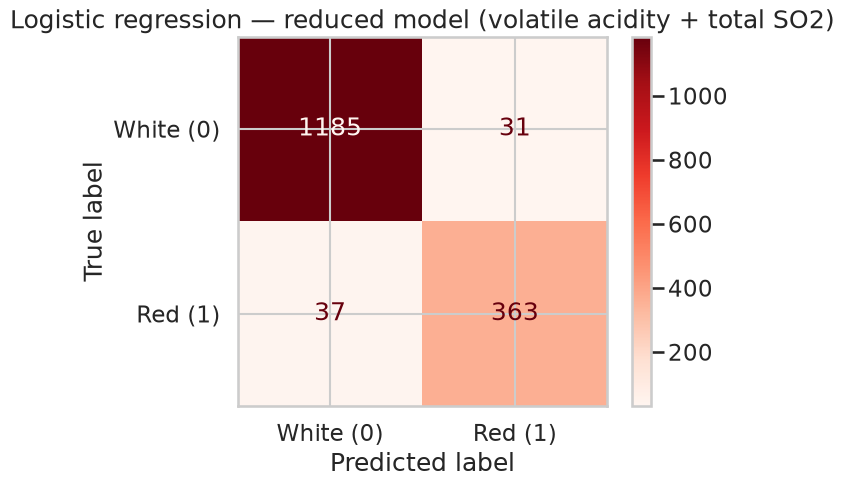

In [9]:
_ = evaluate(
    lambda X: reduced_fit.predict(sm.add_constant(X, has_constant="add")),
    Xr_test,
    labels_test,
    "Logistic regression — reduced model (volatile acidity + total SO2)",
)

The full model is essentially perfect (as expected — with 11 predictors on a
dataset this size, several are highly redundant with `type`). The 2-feature model gives
up a few points of accuracy but stays highly interpretable: `volatile acidity` and
`total sulfur dioxide` alone recover most of the class signal.

## 4. Principal Component Analysis

Instead of hand-picking features, PCA finds the linear combinations of all 11 features
that capture the most variance. Here we look at how much of the dataset's variance (and
downstream classification signal) survives an aggressive reduction to just 2 components.

In [10]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_features = pca.fit_transform(features)

evr = pca.explained_variance_ratio_
print(f"Explained variance ratio: {evr}")
print(f"Total explained variance (2 components): {evr.sum():.3f}")

Explained variance ratio: [0.30496612 0.18394275]
Total explained variance (2 components): 0.489


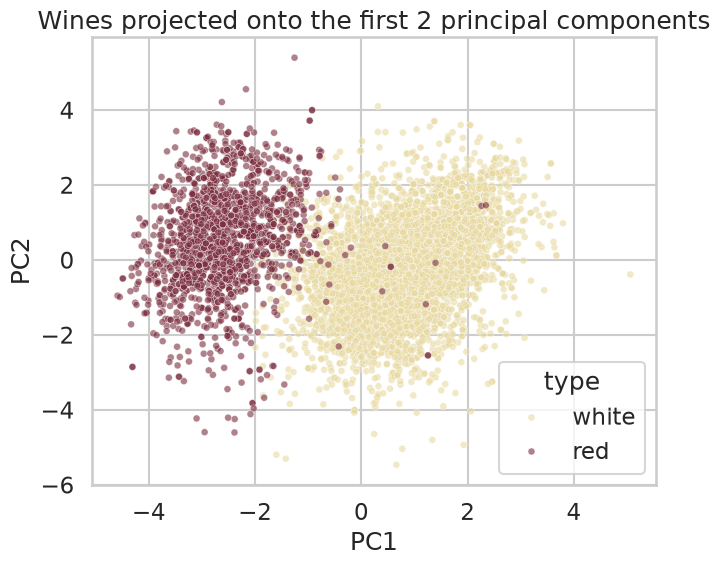

In [11]:
pca_df = pd.DataFrame(pca_features, columns=["PC1", "PC2"], index=features.index)
pca_df["type"] = labels.map({0: "white", 1: "red"})

plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=pca_df, x="PC1", y="PC2", hue="type",
    palette={"white": "#e8d9a0", "red": "#7b2d3d"},
    alpha=0.6, s=25,
)
plt.title("Wines projected onto the first 2 principal components")
plt.tight_layout()
plt.show()

Two components capture only about **49%** of the total variance, and the scatter
plot shows real overlap between the classes rather than two clean clusters — on variance
alone, this looks like a lossy representation. We fit the same style of logistic model on
these two components to see how much classification signal actually survives.

Train: 4847 rows   Test: 1616 rows
--- Logistic regression — 2 principal components ---
              precision    recall  f1-score   support

   White (0)       0.99      0.99      0.99      1216
     Red (1)       0.98      0.96      0.97       400

    accuracy                           0.98      1616
   macro avg       0.98      0.98      0.98      1616
weighted avg       0.98      0.98      0.98      1616



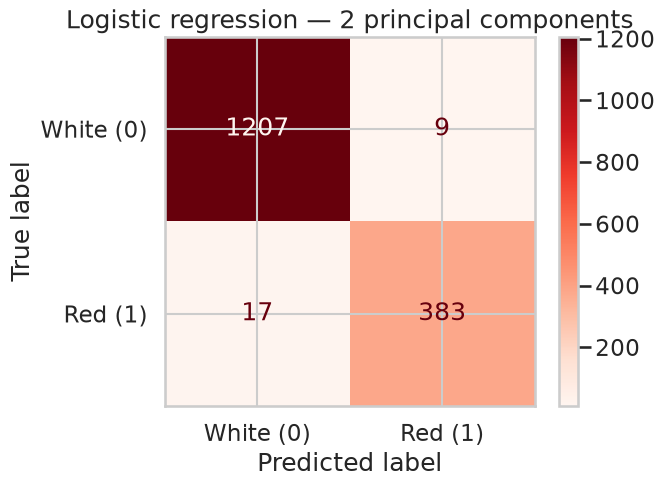

In [12]:
pca_Xtr, pca_Xte, pca_ytr, pca_yte = train_test_split(
    pca_features, labels, test_size=0.25, random_state=RANDOM_STATE
)
print(f"Train: {len(pca_Xtr)} rows   Test: {len(pca_Xte)} rows")

pca_logit = sm.Logit(pca_ytr, sm.add_constant(pca_Xtr))
pca_fit = pca_logit.fit(disp=False)

_ = evaluate(
    lambda X: pca_fit.predict(sm.add_constant(X, has_constant="add")),
    pca_Xte,
    pca_yte,
    "Logistic regression — 2 principal components",
)

Surprisingly, the 2-component PCA model actually **outperforms** the hand-picked
2-feature model from §3.2 (about 98% vs. 96% accuracy), despite explaining under half the
total variance. The takeaway is a useful correction to the "PCA throws away
interpretability for nothing" intuition: because red and white wines differ across *many*
correlated features at once (acidity, sulfur dioxide, chlorides, density all move
together), the top variance-maximizing directions happen to align well with the
class-separating direction here. That won't hold for every dataset — PCA optimizes for
variance, not class separability, and the two only agree when the label happens to be the
dataset's dominant source of variation — but in this case it does, and a fully unsupervised
2D projection matches the full 11-feature model's f1-score for the minority (red) class.

## 5. Support Vector Machine

Finally, a linear-kernel SVM on the full (power-transformed) feature set, with `C` tuned
via grid search and cross-validation.

In [13]:
param_grid = {"C": [0.0001, 0.001, 0.1, 1, 10]}

svm_search = GridSearchCV(
    SVC(kernel="linear", class_weight="balanced"),
    param_grid,
    n_jobs=-1,
)
svm_search.fit(features_train, labels_train)

print("Best C:", svm_search.best_params_["C"])
print("Best estimator:", svm_search.best_estimator_)

Best C: 10
Best estimator: SVC(C=10, class_weight='balanced', kernel='linear')


              precision    recall  f1-score   support

   White (0)       1.00      0.99      0.99      1216
     Red (1)       0.98      0.99      0.98       400

    accuracy                           0.99      1616
   macro avg       0.99      0.99      0.99      1616
weighted avg       0.99      0.99      0.99      1616



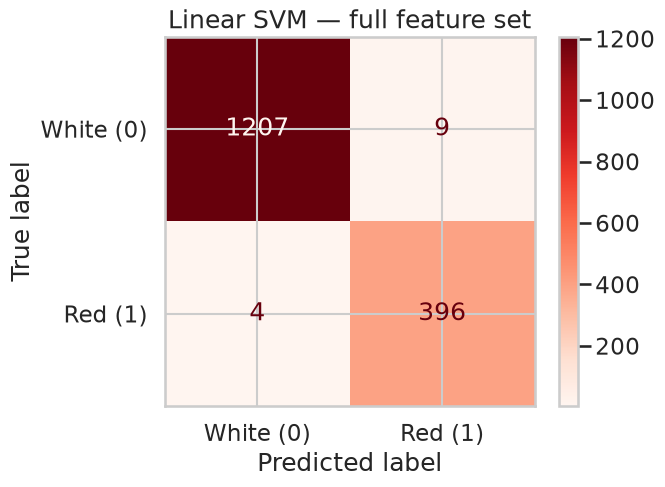

In [14]:
svm_preds = svm_search.predict(features_test)

print(classification_report(labels_test, svm_preds, target_names=["White (0)", "Red (1)"]))

cm = confusion_matrix(labels_test, svm_preds)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["White (0)", "Red (1)"]).plot(cmap="Reds")
plt.title("Linear SVM — full feature set")
plt.show()

## 6. Model comparison

| Model | Features | Accuracy |
|---|---|---|
| Logistic regression (full) | 11 | ~0.99 |
| Logistic regression (reduced) | 2 (volatile acidity, total SO2) | ~0.96 |
| Logistic regression (PCA) | 2 (unsupervised) | ~0.98 |
| Linear SVM | 11 | ~0.99 |

The full logistic regression and the linear SVM are essentially tied at the top — not
surprising, since a wine's type turns out to be *very* linearly separable from its
chemistry (sulfur dioxide preservatives and acidity profiles differ substantially between
red and white winemaking processes). Both 2-feature models trade a couple of points of
accuracy for something a full 11-feature model can't offer: a plot you can actually look
at. Between the two, the unsupervised PCA projection edges out the hand-picked pair here —
a reminder that "unsupervised" doesn't automatically mean "worse," especially when the
label of interest happens to align with the data's dominant axes of variation.

### Precision vs. recall, in context

Which metric to optimize for depends entirely on the cost of each error type — a useful
frame borrowed from the exam's conceptual questions:

- **Disease screening** (e.g. flagging patients for quarantine): false negatives are far
  costlier than false positives, since a missed case can spread further. Optimize for
  **recall** — better to over-flag than to miss someone.
- **Fraud accusation** (e.g. unemployment insurance fraud detection): false positives are
  far costlier, since falsely accusing an innocent claimant has serious consequences.
  Optimize for **precision** — only flag cases you're confident about.

For *this* wine classification task there's no asymmetric real-world cost to a
misclassification, so overall accuracy (and the balanced precision/recall shown above) is
the right metric — which is exactly why both the full logistic model and the linear SVM
are strong choices here.

## Conclusion

Red and white wines turn out to be almost perfectly separable using nothing but routine
lab measurements — no sensory data required. A full-feature linear model (logistic
regression or linear SVM) reaches ~99% accuracy, and even collapsing down to just 2
dimensions — whether hand-picked via a correlation check (~96%) or found automatically via
PCA (~98%) — recovers nearly all of that signal. The comparison across all four models is
a good illustration of the trade-off between model complexity and interpretability, and a
reminder not to assume an unsupervised reduction will necessarily lose to a
domain-knowledge-driven one — it depends on how well the label of interest lines up with
the data's dominant axes of variation.

**Data source:** [UCI Machine Learning Repository — Wine Quality Data Set](https://archive.ics.uci.edu/ml/datasets/wine+quality)
(Cortez et al., 2009), served via the [MSU CMSE 202 course data repository](https://github.com/msu-cmse-courses/cmse202-F22-data).